In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_v02_01_SEU',
    #'results_shipsnet_01_SEU',
    #'results_shipsnet_02_SEU',
    #'results_shipsnet_03_SEU',
    ]

df_master = pd.read_csv(r'results_shipsnet_new_uniform\results_shipsnet_v02_01_SEU\_20250806_013752.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_master['folder_name'] = ""
df_master = df_master.drop(df_master.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_master = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_master['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_new_uniform',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_master = pd.concat([df_master, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_master[df_master['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_master['abs_acc_diff'] = df_master['accuracy_change'].abs()
df_master['log_mean_abs_difference'] = df_master['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)

Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_01_SEU\_20250806_013752.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_01_SEU\_20250806_014138.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_01_SEU\_20250806_014145.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_01_SEU\_20250806_022604.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processi

In [3]:
df_master

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,folder_name,abs_acc_diff,log_mean_abs_difference
0,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,0,0.89875,0.91625,0.01750,0.289256,5.618616e-01,NaN,results_shipsnet_v02_01_SEU,0.01750,-0.250371
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,0.89875,0.75500,-0.14375,0.945748,9.559580e+37,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.14375,37.980439
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,0.89875,0.75000,-0.14875,0.969218,2.162142e+38,NaN,results_shipsnet_v02_01_SEU,0.14875,38.334884
3,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,3,0.89875,0.91500,0.01625,0.295262,2.809308e-01,NaN,results_shipsnet_v02_01_SEU,0.01625,-0.551401
4,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,3,0.89875,0.89375,-0.00500,0.288841,6.353964e-01,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.00500,-0.196955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,actRWG,gaussian,0.690937,0.0,1.0,scales,-1,fc1,bias,1,0.75625,0.39000,-0.36625,0.819946,3.062957e+38,NaN,results_shipsnet_v02_01_SEU,0.36625,38.486141
1760,actRWG,gaussian,0.690937,0.0,1.0,locs,-1,fc1,bias,3,0.75625,0.75250,-0.00375,0.273691,1.055437e-02,NaN,results_shipsnet_v02_01_SEU,0.00375,-1.976568
1761,actRWG,gaussian,0.690937,0.0,1.0,scales,-1,fc1,bias,3,0.75625,0.75375,-0.00250,0.273408,9.001223e-01,NaN,results_shipsnet_v02_01_SEU,0.00250,-0.045698
1762,actRWG,gaussian,0.690937,0.0,1.0,locs,-1,fc1,bias,10,0.75625,0.75375,-0.00250,0.274968,1.953125e-03,NaN,results_shipsnet_v02_01_SEU,0.00250,-2.709270


In [4]:
df_master["bit_index"].unique()

array([ 0,  1,  3, 10])

In [5]:
df_master[(df_master['bit_index'] == 1) & (df_master['prior'] == 'uniform')]

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,folder_name,abs_acc_diff,log_mean_abs_difference
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,0.89875,0.75500,-0.14375,0.945748,9.559580e+37,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.14375,37.980439
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,0.89875,0.75000,-0.14875,0.969218,2.162142e+38,NaN,results_shipsnet_v02_01_SEU,0.14875,38.334884
8,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,bias,1,0.89875,0.90750,0.00875,0.293461,1.742523e+38,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.00875,38.241179
9,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,bias,1,0.89875,0.75000,-0.14875,1.000000,1.665448e+38,NaN,results_shipsnet_v02_01_SEU,0.14875,38.221531
15,relu,uniform,0.868437,0.0,1.0,lows,0,conv2,weight,1,0.89875,0.73250,-0.16625,0.956525,1.460014e+38,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.16625,38.164357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241,actRWG,uniform,0.745938,0.0,1.0,widths,-1,conv2,bias,1,0.83250,0.82250,-0.01000,0.274211,2.442740e+38,NaN,results_shipsnet_v02_01_SEU,0.01000,38.387877
1247,actRWG,uniform,0.745938,0.0,1.0,lows,-1,fc1,weight,1,0.83250,0.75625,-0.07625,0.298508,8.132025e+37,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.07625,37.910199
1248,actRWG,uniform,0.745938,0.0,1.0,widths,-1,fc1,weight,1,0.83250,0.29750,-0.53500,0.665346,3.402823e+38,SEU went to NaN or Inf clipping to finite range;,results_shipsnet_v02_01_SEU,0.53500,38.531839
1254,actRWG,uniform,0.745938,0.0,1.0,lows,-1,fc1,bias,1,0.83250,0.75000,-0.08250,0.301009,1.485274e+38,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.08250,38.171807


In [6]:
df_summary = df_master.groupby(['activation_fn',
                   'prior',
                   'param_type',
                   'location_index',
                   'location_layer',
                   'location_module',
                   'folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary

,activation_fn,prior,param_type,location_index,location_layer,location_module,folder_name,abs_acc_diff,softmax_difference
0,actRWG,gaussian,locs,-1,conv1,bias,results_shipsnet_v02_01_SEU,0.003437,0.274832
1,actRWG,gaussian,locs,-1,conv1,weight,results_shipsnet_v02_01_SEU,0.001875,0.273880
2,actRWG,gaussian,locs,-1,conv2,bias,results_shipsnet_v02_01_SEU,0.003125,0.273346
3,actRWG,gaussian,locs,-1,conv2,weight,results_shipsnet_v02_01_SEU,0.002500,0.276497
4,actRWG,gaussian,locs,-1,fc1,bias,results_shipsnet_v02_01_SEU,0.004062,0.273395
...,...,...,...,...,...,...,...,...,...
499,tanh,uniform,widths,0,conv1,weight,results_shipsnet_v02_01_SEU,0.007083,0.287625
500,tanh,uniform,widths,0,conv2,bias,results_shipsnet_v02_01_SEU,0.008750,0.287990
501,tanh,uniform,widths,0,conv2,weight,results_shipsnet_v02_01_SEU,0.001667,0.287078
502,tanh,uniform,widths,0,fc1,bias,results_shipsnet_v02_01_SEU,0.050000,0.525386


In [7]:
df_master.sort_values(by='abs_acc_diff', ascending=False)

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,folder_name,abs_acc_diff,log_mean_abs_difference
197,relu,gaussian,0.871563,0.0,1.0,locs,0,fc1,weight,1,0.91375,0.24875,-0.66500,0.623616,2.898069e+37,NaN,results_shipsnet_v02_01_SEU,0.66500,37.462109
240,relu,gaussian,0.871563,0.0,1.0,scales,-1,fc1,weight,1,0.91375,0.25125,-0.66250,0.999086,3.080687e+38,NaN,results_shipsnet_v02_01_SEU,0.66250,38.488648
239,relu,gaussian,0.871563,0.0,1.0,locs,-1,fc1,weight,1,0.91375,0.25125,-0.66250,0.708025,3.589996e+36,NaN,results_shipsnet_v02_01_SEU,0.66250,36.555094
156,relu,laplace,0.870313,0.0,1.0,scales,-1,fc1,weight,1,0.90625,0.24750,-0.65875,0.993655,2.656706e+38,NaN,results_shipsnet_v02_01_SEU,0.65875,38.424343
155,relu,laplace,0.870313,0.0,1.0,locs,-1,fc1,weight,1,0.90625,0.25000,-0.65625,0.999664,3.665625e+37,NaN,results_shipsnet_v02_01_SEU,0.65625,37.564148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,actWG,uniform,0.777813,0.0,1.0,lows,-1,conv2,bias,3,0.86375,0.86375,0.00000,0.283067,2.731518e-01,NaN,results_shipsnet_v02_01_SEU,0.00000,-0.563596
1007,actWG,uniform,0.777813,0.0,1.0,widths,-1,fc1,bias,10,0.86375,0.86375,0.00000,0.282632,1.250000e-01,NaN,results_shipsnet_v02_01_SEU,0.00000,-0.903090
925,actWG,uniform,0.777813,0.0,1.0,lows,0,conv1,weight,1,0.86375,0.86375,0.00000,0.281780,8.703882e+37,AutoUniform width adjusted;,results_shipsnet_v02_01_SEU,0.00000,37.939713
1699,actRWG,gaussian,0.690937,0.0,1.0,locs,0,conv2,weight,10,0.75625,0.75625,0.00000,0.276577,1.562500e-02,NaN,results_shipsnet_v02_01_SEU,0.00000,-1.806180


In [8]:
#df_master[df_master['bit_index']==1].to_csv("index_1_check.csv", index=False)

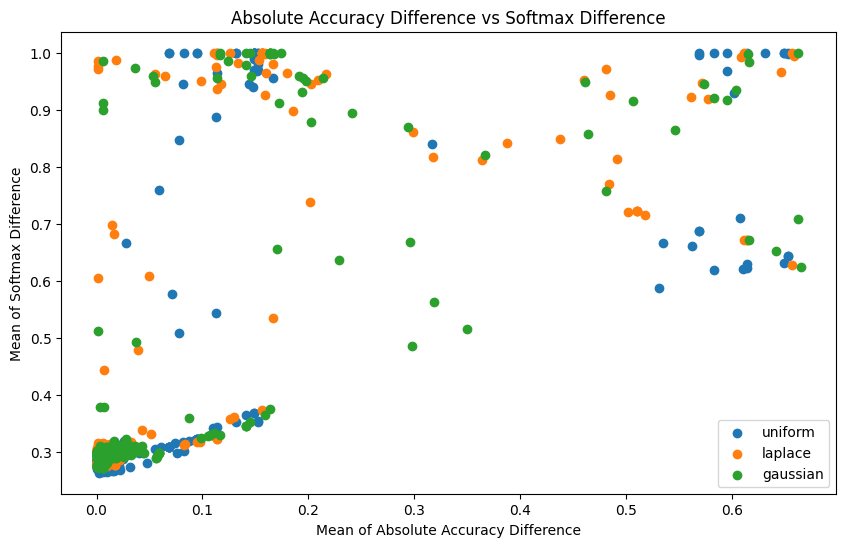

In [9]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for prior in df_master['prior'].unique():
    subset = df_master[df_master['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

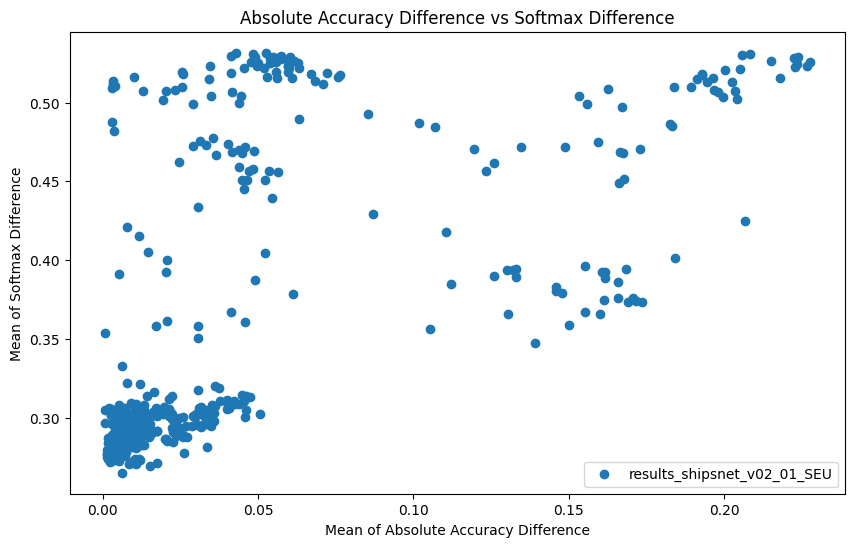

In [10]:
# make a scatter plot of abs_acc_diff vs softmax_difference
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for folder in df_summary['folder_name'].unique():
    subset = df_summary[df_summary['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()
plt.show()

In [11]:
df_summary_2 = df_master.groupby(['location_layer',
                                  'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_2

,location_layer,location_module,abs_acc_diff,softmax_difference
0,conv1,bias,0.012343,0.304639
1,conv1,weight,0.019562,0.318815
2,conv2,bias,0.012581,0.323127
3,conv2,weight,0.020472,0.354320
4,fc1,bias,0.081033,0.414595
5,fc1,weight,0.102615,0.407742


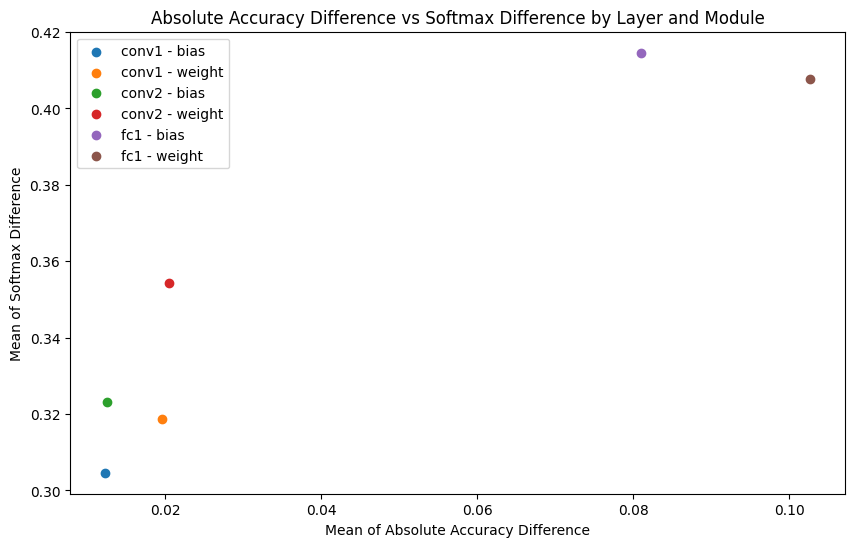

In [12]:
# make a scatter plot of abs_acc_diff vs softmax_difference
# create different shape by location_layer and location_module
plt.figure(figsize=(10, 6))
for layer in df_summary_2['location_layer'].unique():
    for module in df_summary_2['location_module'].unique():
        subset = df_summary_2[(df_summary_2['location_layer'] == layer) & (df_summary_2['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [13]:
df_summary_3 = df_master.groupby(['activation_fn'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_3

,activation_fn,abs_acc_diff,softmax_difference
0,actRWG,0.025397,0.333031
1,actWG,0.032039,0.327738
2,relu,0.067510,0.443464
3,relu6,0.040193,0.346861
4,sigmoid,0.038051,0.329224
5,sin,0.052688,0.353940
6,tanh,0.034162,0.342853


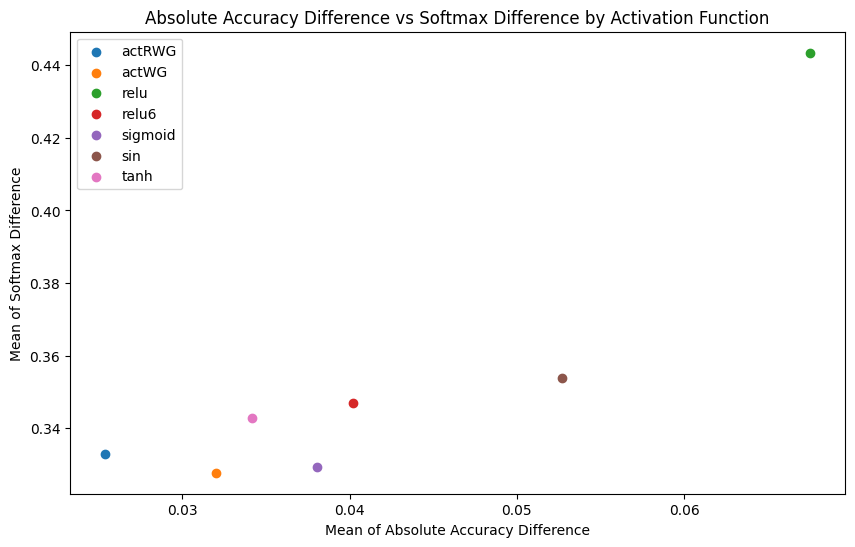

In [14]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for activation in df_summary_3['activation_fn'].unique():
    subset = df_summary_3[df_summary_3['activation_fn'] == activation]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=activation)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Activation Function')
plt.legend()

In [15]:
df_summary_4 = df_master.groupby(['prior'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_4

,prior,abs_acc_diff,softmax_difference
0,gaussian,0.039118,0.352478
1,laplace,0.039926,0.360200
2,uniform,0.045259,0.348941


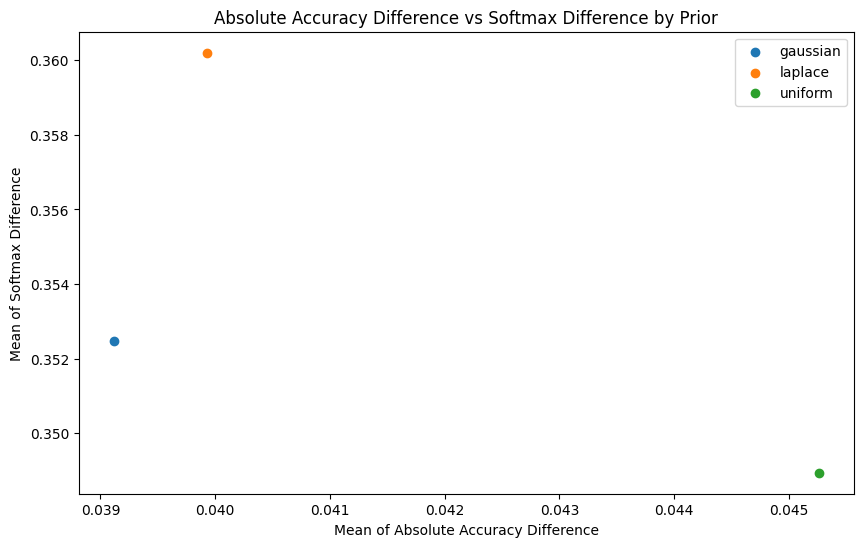

In [16]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))
for prior in df_summary_4['prior'].unique():
    subset = df_summary_4[df_summary_4['prior'] == prior]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=prior)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior')
plt.legend()
plt.show()

In [17]:
df_summary_5 = df_master.groupby(['prior','param_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_5

,prior,param_type,abs_acc_diff,softmax_difference
0,gaussian,locs,0.027708,0.317055
1,gaussian,scales,0.054330,0.399710
2,laplace,locs,0.031838,0.323898
3,laplace,scales,0.050709,0.408602
4,uniform,lows,0.037686,0.317501
5,uniform,widths,0.055357,0.390861


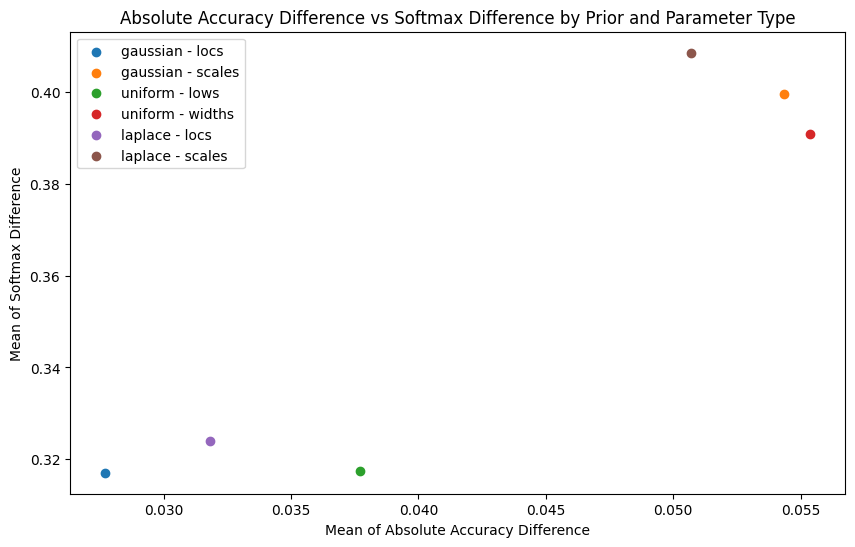

In [18]:
# make a scatter plot of abs_acc_diff vs softmax_difference
plt.figure(figsize=(10, 6))

# make a custom cumbination of prior and param_type
param_dict = {
    'gaussian': ['locs','scales'],
    'uniform': ['lows','widths'],
    'laplace': ['locs','scales'],}

# giva a very contrast different color other that seaborn-darkgrid
import matplotlib.pyplot as plt
#plt.style.use('seaborn-darkgrid')

for prior in param_dict.keys():
    for param_type in param_dict[prior]:
        subset = df_summary_5[(df_summary_5['prior'] == prior) & (df_summary_5['param_type'] == param_type)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{prior} - {param_type}')


plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Prior and Parameter Type')
plt.legend()
plt.show()

In [19]:
df_summary_6 = df_master.groupby(['folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_6

,folder_name,abs_acc_diff,softmax_difference
0,results_shipsnet_v02_01_SEU,0.041434,0.353873


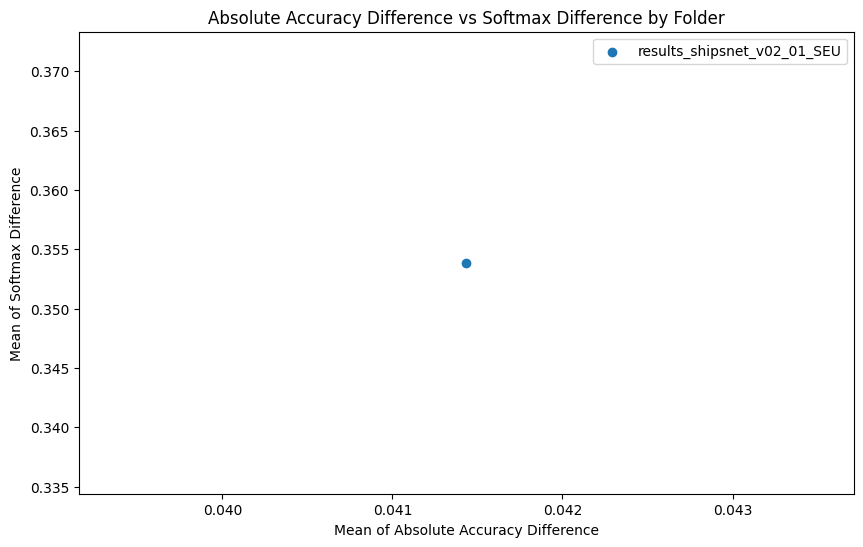

In [20]:
# make a scatter plot of abs_acc_diff vs softmax_difference from df_summary_6
plt.figure(figsize=(10, 6))
for folder in df_summary_6['folder_name'].unique():
    subset = df_summary_6[df_summary_6['folder_name'] == folder]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=folder)
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Folder')
plt.legend()
plt.show()


In [21]:
df_summary_7 = df_master.groupby(['location_index','location_layer', 'location_module'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_7

,location_index,location_layer,location_module,abs_acc_diff,softmax_difference
0,-1,conv1,bias,0.012355,0.304727
1,-1,conv1,weight,0.019796,0.318517
2,-1,conv2,bias,0.013214,0.328100
3,-1,conv2,weight,0.020000,0.337044
4,-1,fc1,bias,0.103121,0.389346
5,-1,fc1,weight,0.117968,0.400716
6,0,conv1,bias,0.012330,0.304551
7,0,conv1,weight,0.019328,0.319113
8,0,conv2,bias,0.011947,0.318154
9,0,conv2,weight,0.020944,0.371596


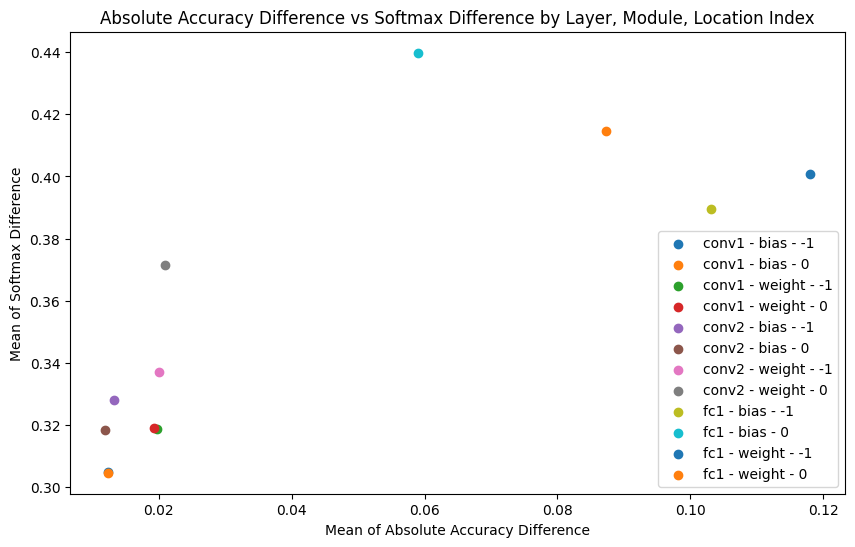

In [22]:
plt.figure(figsize=(10, 6))
for layer in df_summary_7['location_layer'].unique():
    for module in df_summary_7['location_module'].unique():
        for location_index in df_summary_7['location_index'].unique():
            subset = df_summary_7[(df_summary_7['location_layer'] == layer) & (df_summary_7['location_module'] == module) & (df_summary_7['location_index'] == location_index)]
            plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'],label=f'{layer} - {module} - {location_index}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer, Module, Location Index')
plt.legend()
plt.show()

In [ ]:
# filter df to only show those with prior_b = 1
prior_b_filter = 1.0
activation_fn_filter = 'actWG'
prior_filter = 'gaussian'
param_type_filter = 'locs'


df_target = df_master[(df_master['prior_b'] == prior_b_filter) & 
                      (df_master['activation_fn'] == activation_fn_filter) &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == prior_filter) &
                      (df_master['param_type'] == param_type_filter)].reset_index(drop=True)

#mean_acc_diff = df_target['abs_acc_diff'].mean()

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
# plot the result
# x axis is the absoulte value of the difference of accuracy
# y axis is the log of the mean_abs_difference
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

abs_acc_change_mean = df_target[df_target['accuracy_change'].notna()]['accuracy_change'].abs().mean()

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
# add folder_of_interest, prior_b, activation_fn, prior, param_type to the title
plt.title(f'Absolute Mean in Accuracy vs Log Mean Absolute Difference\nShipsNet SEU Analysis: {folder_of_interest} | Prior b: {prior_b_filter} | \nActivation Function: {activation_fn_filter} | Prior: {prior_filter} | Param Type: {param_type_filter}\n Mean Accuracy Difference: {abs_acc_change_mean:.4f}')
#plt.title('Absolute Mean in Accuracy vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
stopdeh

In [ ]:
df_target

In [ ]:
df_target = df_master[(df_master['prior_b'] == 1.0) & 
                      (df_master['activation_fn'] == 'relu') &
                      #(df_master['bit_index'] == 1) &
                      (df_master['prior'] == 'gaussian') &
                      (df_master['param_type'] == 'scales')].reset_index(drop=True)

#df_target = df_target[df_target['activation_fn'] == 'relu'].reset_index(drop=True)
#df_target = df_target[df_target['bit_index'] == 1].reset_index(drop=True)
#df_target = df_target[df_target['prior'] == 'gaussian'].reset_index(drop=True)
df_target

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_target['abs_acc_diff'] = df_target['accuracy_change'].abs()
df_target['log_mean_abs_difference'] = df_target['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else pd.np.nan)

#color by the bit_index
df_target['bit_index'] = df_target['bit_index'].astype(str)

plt.figure(figsize=(10, 6))
#plt.scatter(df_target['abs_acc_diff'], df_target['log_mean_abs_difference'], alpha=0.5)
plt.title('Softmax Difference vs Log Mean Absolute Difference')
plt.xlabel('Absolute Difference of Accuracy')
plt.ylabel('Log Mean Absolute Difference')
#plt.yscale('log')

# create a dictionary to map bit_index to colors
colors = {'0': 'blue', 
          '1': 'orange', 
          '3': 'green', 
          '6': 'red', 
          '10': 'purple', 
          '15': 'brown', 
          '21': 'pink', 
          '30': 'gray'}

plt.scatter(df_target['abs_acc_diff'], 
            df_target['log_mean_abs_difference'],
            c=df_target['bit_index'].map(colors),
            alpha=0.5, label=df_target['bit_index'])

#show legend
#plt.colorbar(label='Bit Index')
plt.grid(True)
plt.show()

In [ ]:
def plot_seu_result():
    """
    input : what variables to show, what parameters to filter
    output : show graph
    """

    # plot the graph

    pass